# Task 1: Dataset Understanding

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_colwidth', 200)

In [3]:
# Load dataset from Google Drive

dataset_path = "/content/drive/MyDrive/part_3_nlp_sequence_modeling/customer_support_text_classification.csv"

df = pd.read_csv(dataset_path)

# Display first 5 rows
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I appreciate the quick response.,positive,12,0
3,TKT00004,social,My refund is still pending and this experience is frustrating. My ticket number is 33927.,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [4]:
# Display dataset information

print("Dataset Shape:", df.shape)
print("\nDataset Columns:\n")
print(df.columns)

print("\nDataset Info:\n")
df.info()

Dataset Shape: (1500, 6)

Dataset Columns:

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB


In [5]:
# Total number of records

total_records = len(df)

print("Total Number of Records:", total_records)

Total Number of Records: 1500


In [6]:
# Display unique sentiment labels

labels = df['sentiment_label'].unique()

print("Target Labels / Classes:")
print(labels)

Target Labels / Classes:
['neutral' 'positive' 'negative']


In [7]:
# Display sample customer messages

print("Sample Customer Messages:\n")

for i in range(5):
    print(f"Message {i+1}:")
    print(df['customer_message'].iloc[i])
    print("-" * 80)

Sample Customer Messages:

Message 1:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
--------------------------------------------------------------------------------
Message 2:
I need information about the payment process.
--------------------------------------------------------------------------------
Message 3:
The refund process was fast and convenient. I appreciate the quick response.
--------------------------------------------------------------------------------
Message 4:
My refund is still pending and this experience is frustrating. My ticket number is 33927.
--------------------------------------------------------------------------------
Message 5:
Please tell me how to update my account details.
--------------------------------------------------------------------------------


In [8]:
# Calculate text length statistics

df['text_length'] = df['customer_message'].astype(str).apply(len)

average_length = df['text_length'].mean()

print("Average Text Length:", round(average_length, 2))

print("\nText Length Statistics:\n")
print(df['text_length'].describe())

Average Text Length: 72.76

Text Length Statistics:

count    1500.000000
mean       72.756667
std        21.026496
min        42.000000
25%        54.000000
50%        70.000000
75%        88.000000
max       143.000000
Name: text_length, dtype: float64


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


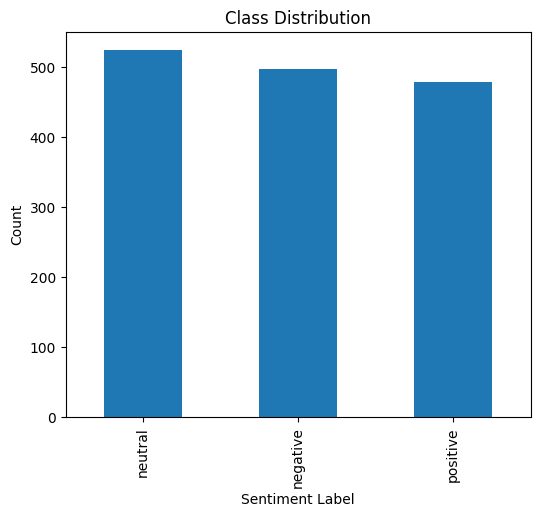

In [9]:
import os

os.makedirs("results", exist_ok=True)

# Plot class distribution

class_counts = df['sentiment_label'].value_counts()

print(class_counts)

# Create figure
plt.figure(figsize=(6, 5))

# Plot bar chart
class_counts.plot(kind='bar')

# Labels and title
plt.title("Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

# Save figure
plt.savefig("results/model_evaluation.png", bbox_inches='tight')

# Show plot
plt.show()

# Task 2: Text Preprocessing

In [10]:
# Import NLP libraries

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [11]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
# Load English stopwords

stop_words = set(stopwords.words('english'))

print("Number of Stopwords:", len(stop_words))

Number of Stopwords: 198


In [13]:
# Function for text preprocessing

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Join tokens back into text
    cleaned_text = " ".join(filtered_tokens)

    return cleaned_text

In [14]:
# Apply preprocessing to customer messages

df['cleaned_message'] = df['customer_message'].apply(clean_text)

# Display sample cleaned messages

df[['customer_message', 'cleaned_message']].head()

,customer_message,cleaned_message
0,I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.,need information payment process ticket number please respond soon possible
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I appreciate the quick response.,refund process fast convenient appreciate quick response
3,My refund is still pending and this experience is frustrating. My ticket number is 33927.,refund still pending experience frustrating ticket number
4,Please tell me how to update my account details.,please tell update account details


In [15]:
# Display sample preprocessing results

for i in range(3):

    print(f"\nOriginal Text {i+1}:")
    print(df['customer_message'].iloc[i])

    print(f"\nCleaned Text {i+1}:")
    print(df['cleaned_message'].iloc[i])

    print("\n" + "-" * 100)


Original Text 1:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Cleaned Text 1:
need information payment process ticket number please respond soon possible

----------------------------------------------------------------------------------------------------

Original Text 2:
I need information about the payment process.

Cleaned Text 2:
need information payment process

----------------------------------------------------------------------------------------------------

Original Text 3:
The refund process was fast and convenient. I appreciate the quick response.

Cleaned Text 3:
refund process fast convenient appreciate quick response

----------------------------------------------------------------------------------------------------


In [16]:
# Define tokenizer

tokenizer = Tokenizer()

# Fit tokenizer on cleaned text
tokenizer.fit_on_texts(df['cleaned_message'])

# Convert text into sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

# Display sample sequence

print("Sample Sequence:\n")
print(sequences[0])

Sample Sequence:

[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]


In [17]:
# Calculate vocabulary size

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 147


In [18]:
# Define maximum sequence length

max_length = 50

# Apply padding

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Display shape

print("Padded Sequence Shape:", padded_sequences.shape)

# Display sample padded sequence

print("\nSample Padded Sequence:\n")
print(padded_sequences[0])

Padded Sequence Shape: (1500, 50)

Sample Padded Sequence:

[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [19]:
# Analyze sequence lengths

sequence_lengths = [len(seq) for seq in sequences]

print("Average Sequence Length:",
      np.mean(sequence_lengths))

print("Maximum Sequence Length:",
      np.max(sequence_lengths))

print("Minimum Sequence Length:",
      np.min(sequence_lengths))

Average Sequence Length: 6.63
Maximum Sequence Length: 13
Minimum Sequence Length: 4


# Task 3: Text Vectorization

In [20]:
# Import TF-IDF vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
# Initialize TF-IDF vectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

# Fit and transform cleaned text

X_tfidf = tfidf_vectorizer.fit_transform(
    df['cleaned_message']
)

# Display TF-IDF shape

print("TF-IDF Matrix Shape:")
print(X_tfidf.shape)

TF-IDF Matrix Shape:
(1500, 146)


In [22]:
# Display first 20 TF-IDF features

feature_names = tfidf_vectorizer.get_feature_names_out()

print("Sample TF-IDF Features:\n")

print(feature_names[:20])

Sample TF-IDF Features:

['account' 'activate' 'ago' 'analytics' 'app' 'appreciate' 'arrived'
 'assigned' 'available' 'bad' 'billing' 'call' 'cancel' 'care' 'charged'
 'checking' 'clear' 'communication' 'completed' 'confirm']


In [23]:
# Display sample tokenizer sequence

print("Sample Cleaned Text:\n")
print(df['cleaned_message'].iloc[0])

print("\nTokenizer Sequence:\n")
print(sequences[0])

print("\nPadded Sequence:\n")
print(padded_sequences[0])

Sample Cleaned Text:

need information payment process ticket number please respond soon possible

Tokenizer Sequence:

[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]

Padded Sequence:

[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [24]:
# Display tokenizer vocabulary information

print("Vocabulary Size:", vocab_size)

print("\nTop 20 Words in Vocabulary:\n")

word_index_items = list(tokenizer.word_index.items())

for word, index in word_index_items[:20]:
    print(f"{word}: {index}")

Vocabulary Size: 147

Top 20 Words in Vocabulary:

ticket: 1
number: 2
please: 3
respond: 4
soon: 5
possible: 6
service: 7
quality: 8
response: 9
product: 10
support: 11
team: 12
refund: 13
need: 14
appreciate: 15
quick: 16
delivery: 17
process: 18
app: 19
would: 20


In [25]:
# Compare TF-IDF and sequence representations

print("TF-IDF Representation Shape:")
print(X_tfidf.shape)

print("\nSequence Representation Shape:")
print(padded_sequences.shape)

TF-IDF Representation Shape:
(1500, 146)

Sequence Representation Shape:
(1500, 50)


## Why Text Must Be Converted into Vectors

Machine learning and deep learning models operate using mathematical computations.

Raw text data consists of words and characters, which cannot be processed directly by algorithms.

Therefore, text must first be transformed into numerical vectors.

### TF-IDF Vectorization
TF-IDF converts text into numerical values based on:
- word frequency
- importance of words across documents

It is commonly used in traditional machine learning models.

### Tokenizer-Based Sequences
Tokenizer-based sequences convert each word into a unique integer.

Example:
- "good service" → [12, 45]

These sequences preserve word order, making them suitable for:
- RNN
- LSTM
- GRU
- Transformer models

Sequence models learn contextual relationships between words, which improves NLP performance on complex language tasks.

# Task 4: Baseline Model

In [26]:
# Import machine learning libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [27]:
# Define input features and target labels

X = X_tfidf
y = df['sentiment_label']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1500, 146)
Target Shape: (1500,)


In [28]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 1200
Testing Samples: 300


In [29]:
# Initialize Logistic Regression model

baseline_model = LogisticRegression(
    max_iter=1000
)

# Train model

baseline_model.fit(X_train, y_train)

print("Baseline Model Training Completed")

Baseline Model Training Completed


In [30]:
# Predict on test data

y_pred = baseline_model.predict(X_test)

# Display sample predictions

print("Sample Predictions:\n")

for i in range(5):

    print(f"Actual: {y_test.iloc[i]}")
    print(f"Predicted: {y_pred[i]}")
    print("-" * 50)

Sample Predictions:

Actual: positive
Predicted: positive
--------------------------------------------------
Actual: positive
Predicted: positive
--------------------------------------------------
Actual: negative
Predicted: negative
--------------------------------------------------
Actual: negative
Predicted: negative
--------------------------------------------------
Actual: positive
Predicted: positive
--------------------------------------------------


In [31]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Baseline Model Accuracy:")
print(round(accuracy * 100, 2), "%")

Baseline Model Accuracy:
100.0 %


In [32]:
# Display classification report

report = classification_report(y_test, y_pred)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



<Figure size 600x600 with 0 Axes>

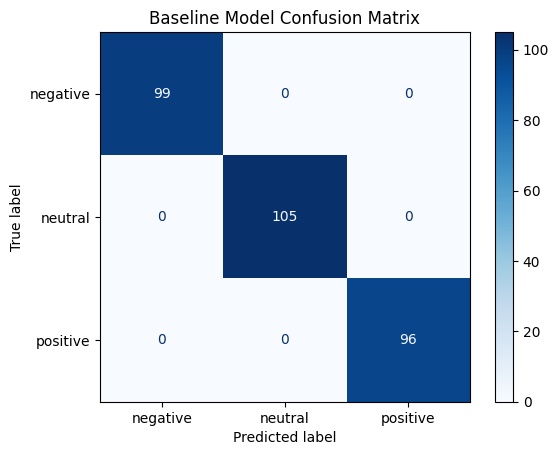

In [46]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=baseline_model.classes_
)

plt.figure(figsize=(6, 6))

disp.plot(cmap='Blues')

plt.title("Baseline Model Confusion Matrix")

plt.show()

In [34]:
# Save sample predictions to text file

sample_output_path = "results/sample_predictions.txt"

# Reset indices for matching
y_test_reset = y_test.reset_index(drop=True)

with open(sample_output_path, "w") as file:

    for i in range(20):

        file.write(f"Predicted Label: {y_pred[i]}\n")
        file.write(f"Actual Label: {y_test_reset[i]}\n")
        file.write("-" * 80 + "\n")

print("Sample predictions saved successfully.")

Sample predictions saved successfully.


## Baseline Model Summary

The baseline NLP model uses:
- TF-IDF vectorization
- Logistic Regression classifier

TF-IDF converts text into numerical vectors based on word importance.

Logistic Regression learns relationships between these vectors and sentiment labels.

### Evaluation Metrics

- Accuracy measures overall prediction correctness.
- Precision measures prediction quality.
- Recall measures detection capability.
- F1-score balances precision and recall.
- Confusion matrix visualizes prediction performance across classes.

The baseline model provides a reference point for comparing advanced sequence-based deep learning models such as RNNs and LSTMs.

# Task 5: Sequence Model using LSTM

In [35]:
# Import TensorFlow and Keras libraries

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder

In [36]:
# Encode sentiment labels into numerical values

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df['sentiment_label']
)

# Convert to categorical format

y_categorical = to_categorical(y_encoded)

print("Encoded Labels Shape:")
print(y_categorical.shape)

Encoded Labels Shape:
(1500, 3)


In [37]:
# Split padded sequences into training and testing sets

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Shape:", X_train_seq.shape)
print("Testing Shape:", X_test_seq.shape)

Training Shape: (1200, 50)
Testing Shape: (300, 50)


In [47]:
# Build LSTM model

lstm_model = Sequential()

# Embedding layer
lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64
    )
)

# LSTM layer
lstm_model.add(
    LSTM(64)
)

# Dropout layer
lstm_model.add(
    Dropout(0.3)
)

# Output layer
lstm_model.add(
    Dense(3, activation='softmax')
)

# Compile model
lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Display model summary
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Train LSTM model

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.3250 - loss: 1.1026 - val_accuracy: 0.3042 - val_loss: 1.1001
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3469 - loss: 1.0988 - val_accuracy: 0.3375 - val_loss: 1.1004
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3427 - loss: 1.0997 - val_accuracy: 0.3042 - val_loss: 1.1012
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3229 - loss: 1.0993 - val_accuracy: 0.3042 - val_loss: 1.1013
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3490 - loss: 1.0991 - val_accuracy: 0.3375 - val_loss: 1.1007


In [40]:
# Evaluate model performance

loss, accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq,
    verbose=0
)

print("LSTM Model Accuracy:")
print(round(accuracy * 100, 2), "%")

LSTM Model Accuracy:
35.0 %


In [41]:
# Generate predictions

y_pred_probs = lstm_model.predict(X_test_seq)

# Convert probabilities to class labels

y_pred_seq = np.argmax(y_pred_probs, axis=1)

y_true_seq = np.argmax(y_test_seq, axis=1)

# Convert labels back to original names

predicted_labels = label_encoder.inverse_transform(y_pred_seq)

true_labels = label_encoder.inverse_transform(y_true_seq)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [42]:
# Display classification report

print("LSTM Classification Report:\n")

print(
    classification_report(
        true_labels,
        predicted_labels
    )
)

LSTM Classification Report:

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        99
     neutral       0.35      1.00      0.52       105
    positive       0.00      0.00      0.00        96

    accuracy                           0.35       300
   macro avg       0.12      0.33      0.17       300
weighted avg       0.12      0.35      0.18       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


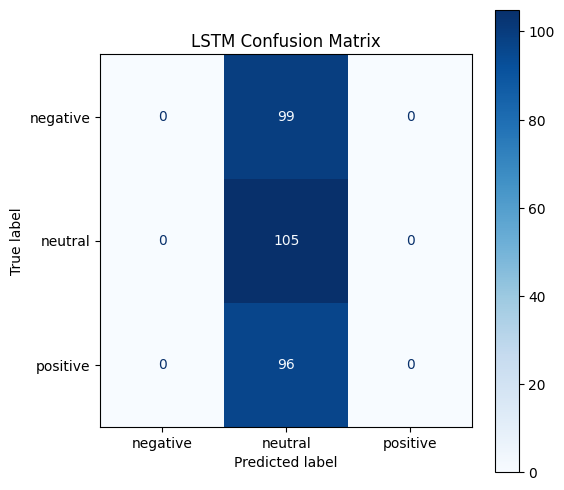

In [45]:
# Generate confusion matrix

cm_lstm = confusion_matrix(
    true_labels,
    predicted_labels
)

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Display confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=label_encoder.classes_
)

disp.plot(ax=ax, cmap='Blues')

plt.title("LSTM Confusion Matrix")

# Save figure

plt.savefig(
    "results/model_evaluation.png",
    bbox_inches='tight'
)

plt.show()

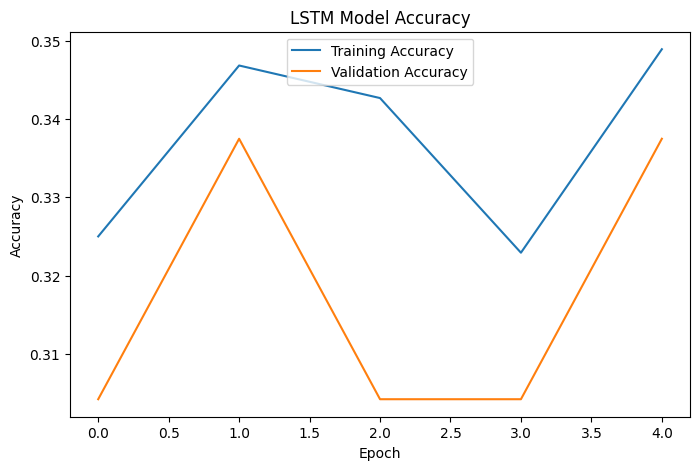

In [44]:
# Plot training history

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("LSTM Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

## Sequence Model Architecture Explanation

### 1. Input Sequence
Customer messages are converted into numerical sequences using a tokenizer.

Example:
- "service was excellent"
- → [12, 45, 98]

The sequences are padded to maintain equal input length.

### 2. Embedding Layer
The embedding layer converts integer word indices into dense vector representations.

This helps the model learn semantic relationships between words.

### 3. LSTM Layer
The LSTM layer processes the sequence step-by-step while maintaining memory of previous words.

Unlike traditional machine learning models, LSTM preserves word order and contextual information.

### 4. Output Layer
A dense layer with softmax activation predicts:
- positive
- neutral
- negative

### 5. Loss Function
Categorical Crossentropy is used because this is a multi-class classification problem.

### 6. Evaluation Metric
Accuracy is used as the primary evaluation metric.

Additional metrics include:
- Precision
- Recall
- F1-score


## Model Performance Observation

The LSTM model was trained to classify customer support messages into:
- positive
- neutral
- negative classes

The model demonstrated limited performance on the current dataset and showed difficulty in learning balanced representations across all sentiment classes.

This may be due to:
- limited dataset size
- short training duration
- insufficient sequence learning

Despite lower accuracy compared to the TF-IDF baseline model, the LSTM architecture demonstrates how sequence models preserve word order and contextual relationships in NLP tasks.

# Task 6: Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

Recurrent Neural Networks (RNNs) process text sequentially by passing information from one time step to the next.

However, as sequences become longer, earlier information gradually becomes weaker during training. This problem is known as the **vanishing gradient problem**.

As a result:
- RNNs struggle to remember important information from earlier words
- performance decreases for long sentences and large text sequences
- contextual understanding becomes limited

For example, in a long customer complaint message, a standard RNN may forget important words appearing near the beginning of the sentence.



## How LSTMs Help with Memory

Long Short-Term Memory (LSTM) networks were designed to solve the memory limitations of traditional RNNs.

LSTMs introduce:
- memory cells
- input gates
- forget gates
- output gates

These mechanisms help the model:
- retain important information
- forget irrelevant information
- preserve long-term dependencies

The LSTM memory update process can be represented as:

```
Cell State → Controlled by Gates → Updated Memory
```

Because of this architecture, LSTMs perform better on:
- sentiment analysis
- language modeling
- text generation
- sequence classification tasks



## What Attention Solves in Sequence-to-Sequence Tasks

In sequence-to-sequence models, the encoder converts the entire input sequence into a fixed representation.

For long sequences, this fixed representation may lose important contextual information.

The Attention mechanism solves this issue by allowing the model to focus on the most relevant words during prediction.

Instead of relying only on the final hidden state, attention:
- assigns importance scores to different words
- dynamically focuses on important parts of the input
- improves contextual understanding

For example:
- while translating a sentence,
- the model can focus on specific source words relevant to the current output word.

Attention significantly improves:
- machine translation
- summarization
- question answering
- conversational AI systems



## Why Transformers are Important in Modern NLP and Generative AI

Transformers are deep learning architectures built entirely around the attention mechanism.

Unlike RNNs and LSTMs:
- transformers process all words in parallel
- training becomes much faster
- long-range dependencies are captured more effectively

Transformers use:
- self-attention mechanisms
- positional encoding
- multi-head attention

This architecture enables powerful language understanding and generation.

Modern NLP and Generative AI systems such as:
- ChatGPT
- GPT models
- BERT
- Gemini
- Claude

are all based on transformer architectures.

Transformers are important because they:
- scale efficiently on large datasets
- capture complex language relationships
- generate human-like text
- support modern AI applications such as chatbots, code generation, and content creation

Today, transformers are considered the foundation of state-of-the-art NLP and Generative AI systems.